# <center>Laboratorium 10<br>Metody Numeryczne</center>

Instrukcja:  
Na zajęciach należy wykonać poniższe zadania, uzupełnić plik main.py, wykonać test na platformie github, a następnie sporządzić sprawozdanie zawierające odpowiedzi z komentarzami.

***Materiały przygotowujące:***


In [83]:
import main
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import scipy.linalg
from numpy.polynomial import polynomial as P

In [84]:
"""Poniższą funkcją nie zastąpiono frob_a w mainie 
ponieważ testerka uważa tamtą za prawidłową,
poniższą faktycznie prawidłową uznając za błędną.
""" 
def one_true_frob(wsp: np.ndarray):
    if isinstance(wsp,np.ndarray):
        m=wsp.shape[0]
        A=np.zeros((m-1,m-1))
        for  i in range(m-2):
            A[i][i+1]=1
        for i in range(m-1):
            A[m-2][i]=-wsp[i]
        return A,np.linalg.eigvals(A),scipy.linalg.schur(A),P.polyroots(wsp)
    else:
        return None

**Cel zajęć:** Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania równań nieliniowych lub inaczej mówiąc metodami znajdowania miejsc zerowych funkcji.
W związku z tym podczas zajęć będziemy rozważać następujący problem:

Dana jest funkcja $f(x)$, należy wyznaczyć argumenty funkcji $x$, dla których $f(x) = 0$ (funkcja jest równa zero). 

Argumenty $x^*$, dla których $f(x)=0$ nazywamy *pierwiastkami*.

Funkcja i jej pochodne zostały zaimplementowane w *main.py*

***Zadanie 1.***  
Dany jest wielomian postaci $W(x)=(x-1)(x-2)\cdot \ldots \cdot (x-20)$.

1. Zdefinuj funkcję *polly_A*, która obliczy współczynniki wielomianu $a_i$ w postaci ogólnej wielomianu $w(x)=a_nx^n+\ldots +a_2x^2+a_1x+1$. Skonstruuj wektor tych współczynników. Użyj funkcji [polyfromroots](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.polynomial.polynomial.polyfromroots.html#numpy.polynomial.polynomial.polyfromroots) oraz *linspace*.
2. Zdefinuj funkcję *roots_20*, która w pętli 20 iteracji będzie:  

   i. konstruować wektor współczynników nowego wielomianu w następujący sposób: do każdego wygenerowanego wektora współczynników dodać losową wartość w postaci $(10^{-10})N(0,1)$. Użyj funkcji [random_sample](https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.random.random_sample.html#numpy.random.random_sample).  
  ii. wyliczyać pierwiaski tego wielomianu za pomocą metody [polyroots](https://docs.scipy.org/doc/numpy/reference/generated/numpy.polynomial.polynomial.polyroots.html#numpy.polynomial.polynomial.polyroots).

3. Narysuj na wykresie te pierwiastki (w każdej iteracji dorysowywać pierwiastki na tym samym rysunku).
4. Określić, który pierwiastek jest najbardziej wrażliwy na zaburzenia.
5. Zaproponować sposób oszacowania uwarunkowania każdego z pierwiastków.

C:\Users\domin\anaconda3\lib\site-packages\numpy\core\_asarray.py:171: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0.5, 0, 'old roots')

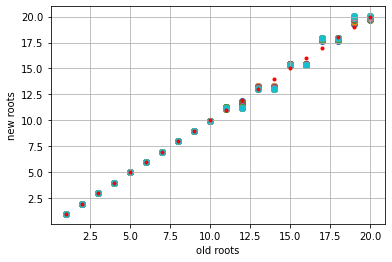

In [85]:
wroot=np.linspace(1,20,20)
wpol=main.polly_A(wroot)
summ=np.ndarray([21])
plt.plot(wroot,wroot,'r.')
for i in range(20):
    wpol,rootnew=main.roots_20(wpol)
    plt.scatter(wroot,rootnew)
plt.grid()
plt.ylabel('new roots')
plt.xlabel('old roots')


C:\Users\domin\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, 'old roots')

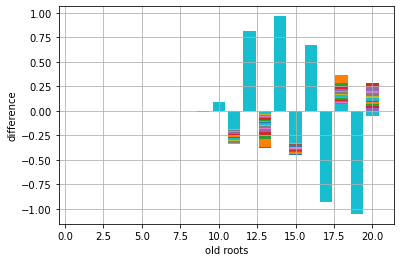

In [94]:
wroot=np.linspace(1,20,20)
wpol=main.polly_A(wroot)
for i in range(20):
    wpol,rootnew=main.roots_20(wpol)
    dif=wroot-rootnew
    plt.bar(wroot,dif)
plt.grid()
plt.ylabel('difference')
plt.xlabel('old roots')

Text(0.5, 0, 'old roots')

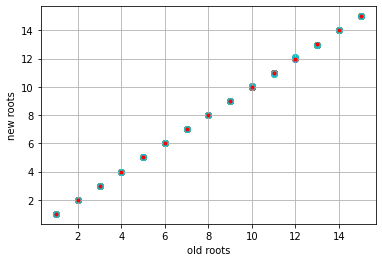

In [87]:
wroot=np.linspace(1,15,15)
wpol=main.polly_A(wroot)
summ=np.ndarray([21])
plt.plot(wroot,wroot,'r.')
for i in range(20):
    wpol,rootnew=main.roots_20(wpol)
    plt.scatter(wroot,rootnew)
plt.grid()
plt.ylabel('new roots')
plt.xlabel('old roots')

C:\Users\domin\anaconda3\lib\site-packages\numpy\core\_asarray.py:171: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order, subok=True)


Text(0.5, 0, 'old roots')

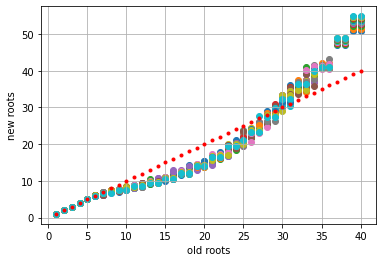

In [88]:
wroot=np.linspace(1,40,40)
wpol=main.polly_A(wroot)
summ=np.ndarray([21])
plt.plot(wroot,wroot,'r.')
for i in range(20):
    wpol,rootnew=main.roots_20(wpol)
    plt.scatter(wroot,rootnew)
plt.grid()
plt.ylabel('new roots')
plt.xlabel('old roots')

Po wykresie wnioskuję że najbardziej wrażliwymi pierwiastkami są 19, którego wartość w wyniku tego się zmniejsza nawet sięgając 18 a także 13 które nieomal sięgnęło 14.
Przy tym niemal niezauważalne zaburzenia występują dla pierwiastkó 1-10.
Wartości 11,13,15 i 18 po pczątkowym wychyleniu zaczęły natomiast wracać do początkowej wartości.
Ponadto wartość pierwiastków 11-17 się zmniejsza natomiast 18,19 i 20 zwiększa się.

Z wykresów pozostałych wielmianów postaci (x-1)(x-2)...(x-n) 
widać że dla n=15 zmiany wywołane zaburzeniami są nieomal niezauważalne a jest to zaledwie o 5 rzędów wiekszy wielomian od podanego w ćwiczeniu u którego zaburzenia mogą już być odczuwalne.

Dla n=40 wachania sięgają nawet ok 18-19 (wartości 39,40). Odporne są zakłocenia są już tylko pierwiastki 1-6, obniżoną wartość mają pierwiastki 8-27, a podwyższoną od 30-40. Widać że większość pierwiastków od 7 występuje w parach o podobnych jeśli nie identycznych (szczególnie u 2 ostanich) wartościach.

Wnioskuję zatem że jeśli jest to możliwe należy używać wielomianów o jak najmniejszym stopniu,
o tych powyżej 40 rzędu zaś lepiej zapomnieć bez odpowednich zabezpieczeń danych, chyba że potrzebujemy tylko jednego najmniejszego miejsca zerowego.

***Zadanie 2.***  
Dany jest wielomian $w_1(x)=(x-1)^8$. Wyznacz numerycznie miejsca zerowego tego wielomianu poprzez wyznaczenie wartości własnych macierzy Frobeniusa. W związku z tym wykonaj następujące czynności:  

1. Zaiplementuj funkcję tworzącą [macierz Frobenusa](https://github.com/KAIR-ISZ/public_lectures/blob/master/Metody%20Numeryczne%202019/Lecture%204%20(nonlinear%20equations)/Metody%20numeryczne%202019%20-%20R%C3%B3wnania%20nieliniowe.pdf) *frob_a*, dla zadanego wektora współczynników wielomianu $w(x)$.  
2. Wyznacz wartości własne przekształconej macierzy za pomocą funkcji [eigvals](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigvals.html#numpy.linalg.eigvals).  
3. Dokonaj rozkładu Schura macierzy zdefiniowanej w punkcie 1. użyj funkcji [schure](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.linalg.schur.html#scipy.linalg.schur).  
4. Porównaj wyniki z funkcją polyroots.

In [89]:
w=np.ones(8)
wsp=main.polly_A(w)
frob,lam,shur,frob_roots=main.frob_a(wsp)
stand=np.ones(9)
print(np.linalg.norm(w - frob_roots))
print(np.linalg.norm(stand - lam))
print(np.linalg.norm(stand - np.diag(shur[0])))

print("Prawidłowy frob :")
frob,lam,shur,frob_roots=one_true_frob(wsp)
print(np.linalg.norm(w - frob_roots))
print(np.linalg.norm(w - lam))
print(np.linalg.norm(w - np.diag(shur[0])))

%timeit -r 100 -n 100 -o P.polyroots(wsp)
%timeit -r 100 -n 100 -o np.linalg.eigvals(frob)

0.0434488025602035
6.448840770508207
5.8986247246018655
Prawidłowy frob :
0.0434488025602035
0.05309224608364849
0.03609691427806772
45.1 µs ± 5.01 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
19.8 µs ± 525 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)


<TimeitResult : 19.8 µs ± 525 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)>

Jak widać wartości własne postaci Schura dają najlepszą dokładność.
Natomiast używanie wartości własnych z macierzy Frobenusa to opłaca się używać tylko jak już wcześniej mamy skądś ową macierz, bowiem znalezienie jej wartości własnych jest ponad dwukrotnie szybsze od polyroots przy "zaledwie" 0.01 straty precyzji.

***Zadanie 3.***  
Dla danego wielomianu $w_2(x) = 243x^7-486x^6+783x^5-990x^4+558x^3-28x^2-72x+16$ wyznacz miejsca zerowe numerycznie, w taki sam sposób jak w zadaniu 2.


In [90]:
w2=np.array([-486,783,-990,558,-28,72,16])
w2=w2/243
frob,lam,shur,frob_roots=one_true_frob(w2)
print(np.diag(shur[0]))

[-1.90447322 -0.02504055 -0.02504055  0.91621023  0.3710239   0.3710239 ]


***Zadanie 4.***

Dany jest wielomian: 
$
w_3(x)= x^5 - 156x^4 - 5x^3 + 780x^2 + 4x - 624
$.
 Wiedząc, że wielomian ten w postaci szeregu Czebyszewa jest następujący 
 $$w_3(x)= (a_0+\frac{a_2}{2}+ \frac{3a_4}{4})T_0(x)+(a_1+\frac{3a_3}{4}+ \frac{5a_5}{8})T_1(x)+(\frac{a_2}{2}+ \frac{a_4}{4})T_2(x)+(\frac{a_3}{4}+ \frac{5a_5}{16})T_3(x)+ (\frac{a_4}{8})T_4 + (\frac{a_5}{16})T_5(x)$$ 
 znajdź pierwiastki wykorzystując funkcję [chebroots](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.chebyshev.chebroots.html).

In [91]:
a=np.array([624,4,780,-5,-156,1])
T0=a[0]+a[2]/2+3/4*a[4]
T1=a[1]+3/4*a[3]+5/8*a[5]
T2=a[2]/2+a[4]/4
T3=a[3]/4+5/16*a[5]
T4=a[4]/8
T5=a[5]/16
print(np.polynomial.chebyshev.chebroots([T1,T2,T3,T4,T5]))

[-2.28744779e+00 -4.57865128e-03  2.29523332e+00  1.55996793e+02]
